# ⚽ Projeto 1 — Quem vai vencer o jogo? (Classificação)
### Previsão de resultados no futebol **feminino** com Machine Learning

**Para estudantes do ensino médio 🇧🇷**

---

Neste projeto vamos construir um modelo de *Machine Learning* (aprendizado de máquina)
capaz de **prever o resultado** de uma partida de futebol feminino:

> 🏠 **Vitória da casa**, 🤝 **Empate**, ou ✈️ **Vitória da visitante**?

Esse tipo de problema — em que o computador precisa escolher entre algumas
**categorias** (classes) — se chama **classificação**.

### O que você vai aprender
1. Como carregar e explorar dados reais de futebol.
2. O que é **engenharia de atributos** (criar informações úteis para o modelo).
3. O conceito de **rating Elo** (uma "nota de força" para cada seleção).
4. Por que usamos **divisão treino/teste cronológica** (respeitando o tempo!).
5. Como treinar, avaliar e comparar modelos de ML.
6. Como usar o modelo para prever jogos da **Seleção Brasileira Feminina** 🇧🇷.

> ⚠️ **Importante:** usamos **apenas jogos do futebol feminino**. Os jogos
> masculinos foram totalmente excluídos deste conjunto de dados.


## 1. Importando as ferramentas

Assim como um mecânico precisa de uma caixa de ferramentas, nós usamos
**bibliotecas** do Python. Cada uma tem uma função:

- `pandas` → trabalhar com tabelas de dados (como uma planilha).
- `numpy` → fazer cálculos com números.
- `matplotlib` e `seaborn` → desenhar gráficos.
- `scikit-learn` (`sklearn`) → os modelos de Machine Learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Ferramentas carregadas com sucesso! ✅")

Ferramentas carregadas com sucesso! ✅


## 2. Carregando os dados

Nossa base de dados tem **milhares de partidas internacionais do futebol feminino**,
desde 1969. Cada linha é um jogo, com as colunas:

| Coluna | Significado |
|---|---|
| `date` | data do jogo |
| `home_team` | seleção que joga em casa |
| `away_team` | seleção visitante |
| `home_score` | gols da casa |
| `away_score` | gols da visitante |
| `tournament` | competição |
| `neutral` | `True` se o jogo foi em campo neutro |


In [2]:
url_csv = "https://raw.githubusercontent.com/martj42/womens-international-results/master/results.csv"

# Lê o arquivo CSV diretamente da internet
jogos = pd.read_csv(url_csv)

# Converte a coluna de datas para o formato de data do pandas
jogos["date"] = pd.to_datetime(jogos["date"])

# Ordena os jogos do mais antigo para o mais recente (MUITO importante!)
jogos = jogos.sort_values("date").reset_index(drop=True)

print(f"Total de jogos: {len(jogos)}")
print(f"Período: {jogos['date'].min().date()} até {jogos['date'].max().date()}")
jogos.head()

Total de jogos: 11650
Período: 1956-09-23 até 2026-06-10


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1956-09-23,Germany,Netherlands,2,1,Friendly,Essen,Germany,False
1,1957-07-28,Germany,England,1,1,Friendly,Stuttgart,Germany,False
2,1957-10-13,Germany,Netherlands,2,0,Friendly,Berlin,Germany,False
3,1957-11-03,Netherlands,Austria,8,1,European Championship,Berlin,Germany,True
4,1957-11-03,Germany,England,0,4,European Championship,Berlin,Germany,False


## 3. Análise exploratória (conhecendo os dados)

Antes de treinar qualquer modelo, um bom cientista de dados **olha para os dados**.
Vamos responder algumas perguntas com gráficos.

### 3.1 Quantos jogos aconteceram por década?
O futebol feminino cresceu muito com o tempo — vamos ver isso no gráfico.

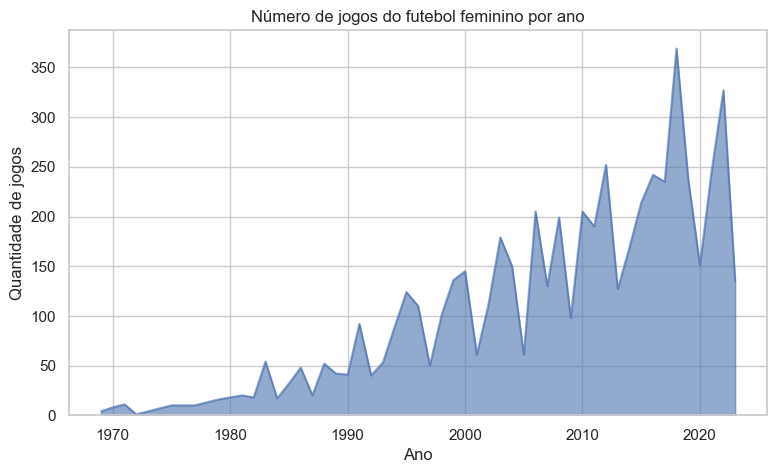

In [ ]:
jogos["ano"] = jogos["date"].dt.year

plt.figure()
jogos.groupby(jogos["date"].dt.year).size().plot(kind="area", alpha=0.6)
plt.title("Número de jogos do futebol feminino por ano")
plt.xlabel("Ano"); plt.ylabel("Quantidade de jogos")
plt.show()

### 3.2 Quem vence mais: a casa ou a visitante?

Vamos criar a nossa coluna-alvo (o que queremos prever): o **resultado**.
Usaremos números para o computador entender:

- `2` = vitória da casa 🏠
- `1` = empate 🤝
- `0` = vitória da visitante ✈️

C:\Users\xx-re\AppData\Local\Temp\ipykernel_32880\1679924147.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem.index, y=contagem.values, palette="viridis")


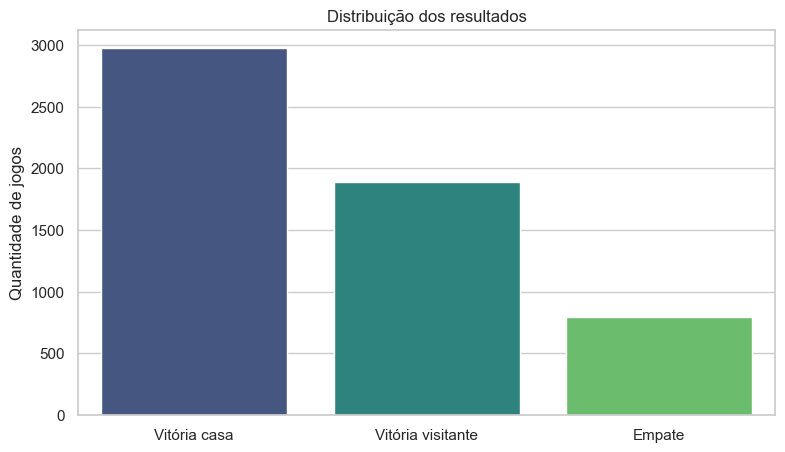

resultado
Vitória casa         52.6
Vitória visitante    33.4
Empate               14.0
Name: proportion, dtype: float64


In [ ]:
def resultado(linha):
    if linha["home_score"] > linha["away_score"]:
        return 2   # casa vence
    elif linha["home_score"] < linha["away_score"]:
        return 0   # visitante vence
    else:
        return 1   # empate

jogos["resultado"] = jogos.apply(resultado, axis=1)

nomes = {2: "Vitória casa", 1: "Empate", 0: "Vitória visitante"}
contagem = jogos["resultado"].map(nomes).value_counts()

plt.figure()
sns.barplot(x=contagem.index, y=contagem.values, palette="viridis")
plt.title("Distribuição dos resultados")
plt.ylabel("Quantidade de jogos"); plt.xlabel("")
plt.show()

print((jogos["resultado"].map(nomes).value_counts(normalize=True) * 100).round(1))

💡 **Observação:** o time da casa vence com mais frequência. Isso é o famoso
**"fator casa"**! Nosso modelo vai aprender a usar essa informação — inclusive
sabendo quando o jogo foi em **campo neutro** (sem dono da casa).

## 4. Engenharia de atributos: o **rating Elo** 🧠

Este é o coração do projeto! Um modelo não consegue prever um jogo só sabendo
os *nomes* das seleções. Precisamos dar a ele uma medida de **força** de cada time.

Vamos usar o **rating Elo**, o mesmo sistema usado no xadrez:

- Toda seleção começa com **1500 pontos**.
- Quem **vence**, ganha pontos; quem **perde**, perde pontos.
- Vencer um time **forte** vale mais pontos do que vencer um time fraco.

A fórmula da *expectativa* de vitória do time da casa é:

$$ E_{casa} = \frac{1}{1 + 10^{-(R_{casa} + \text{fator casa} - R_{visitante})/400}} $$

E a atualização depois do jogo:

$$ R_{novo} = R_{antigo} + K \times (\text{resultado real} - E) $$

> 🔑 **Regra de ouro (sem "trapaça"!):** o Elo de cada jogo é calculado usando
> **apenas os jogos que já aconteceram antes** dele. Nunca usamos o futuro para
> prever o passado — isso se chama evitar **vazamento de dados** (*data leakage*).

In [ ]:
def calcular_elo(jogos, K=32, fator_casa=60, inicial=1500):
    # Percorre os jogos em ordem cronológica e calcula o Elo de cada time.
    # Para cada jogo, guarda o Elo dos times ANTES da partida (sem vazamento).
    rating = {}                       # rating atual de cada seleção
    elo_casa, elo_visit, elo_dif = [], [], []

    for _, j in jogos.iterrows():
        casa, visit = j["home_team"], j["away_team"]
        r_casa = rating.get(casa, inicial)
        r_visit = rating.get(visit, inicial)

        # Se o jogo é em campo neutro, não há vantagem de casa
        vantagem = 0 if j["neutral"] else fator_casa

        # Guarda os ratings ANTES do jogo (é isso que o modelo vai usar)
        elo_casa.append(r_casa)
        elo_visit.append(r_visit)
        elo_dif.append((r_casa + vantagem) - r_visit)

        # Expectativa de vitória da casa
        E = 1 / (1 + 10 ** (-((r_casa + vantagem) - r_visit) / 400))

        # Resultado real (1 = casa venceu, 0.5 = empate, 0 = casa perdeu)
        if j["home_score"] > j["away_score"]: S = 1.0
        elif j["home_score"] < j["away_score"]: S = 0.0
        else: S = 0.5

        # Atualiza os ratings para os próximos jogos
        rating[casa] = r_casa + K * (S - E)
        rating[visit] = r_visit + K * ((1 - S) - (1 - E))

    jogos = jogos.copy()
    jogos["elo_casa"] = elo_casa
    jogos["elo_visitante"] = elo_visit
    jogos["elo_diferenca"] = elo_dif
    jogos["campo_neutro"] = jogos["neutral"].astype(int)
    return jogos, rating

jogos, rating_final = calcular_elo(jogos)
jogos[["date", "home_team", "away_team", "elo_casa", "elo_visitante", "elo_diferenca"]].head()

,date,home_team,away_team,elo_casa,elo_visitante,elo_diferenca
0,1969-11-01,Italy,France,1500.000000,1500.000000,60.000000
1,1969-11-01,Denmark,England,1500.000000,1500.000000,0.000000
2,1969-11-02,England,France,1484.000000,1486.735958,-2.735958
3,1969-11-02,Italy,Denmark,1513.264042,1516.000000,57.264042
4,1970-07-06,England,West Germany,1500.125993,1500.000000,0.125993


### 4.1 O ranking faz sentido?

Uma forma de confiar no nosso Elo é olhar o **ranking final** das seleções.
Se as potências do futebol feminino aparecerem no topo, estamos no caminho certo!

C:\Users\xx-re\AppData\Local\Temp\ipykernel_32880\2469511413.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ranking.values, y=ranking.index, palette="mako")


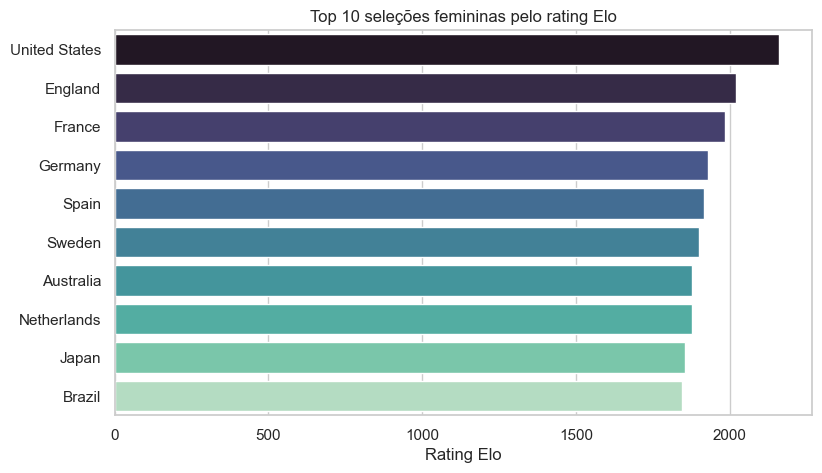

🇧🇷 O Brasil aparece em 10º lugar, com Elo 1847


In [ ]:
ranking = pd.Series(rating_final).sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=ranking.values, y=ranking.index, palette="mako")
plt.title("Top 10 seleções femininas pelo rating Elo")
plt.xlabel("Rating Elo"); plt.ylabel("")
plt.show()

pos_brasil = pd.Series(rating_final).sort_values(ascending=False).index.get_loc("Brazil") + 1
print(f"🇧🇷 O Brasil aparece em {pos_brasil}º lugar, com Elo {rating_final['Brazil']:.0f}")

## 5. Divisão treino/teste **cronológica** ⏳

Para saber se o modelo é bom, precisamos testá-lo em jogos que ele **nunca viu**.

Em muitos problemas de ML, separamos os dados de forma aleatória. Mas aqui temos
uma **linha do tempo**! Não faria sentido treinar com jogos de 2022 para prever
jogos de 2015 — na vida real, só conhecemos o **passado**.

Por isso usamos uma **divisão cronológica**:

- 🟦 **Treino:** todos os jogos **antes de 2019**.
- 🟧 **Teste:** todos os jogos **de 2019 em diante**.

Assim simulamos a situação real: aprender com o passado para prever o futuro.

Jogos de TREINO (antes de 2019): 4560
Jogos de TESTE  (2019 em diante): 1097


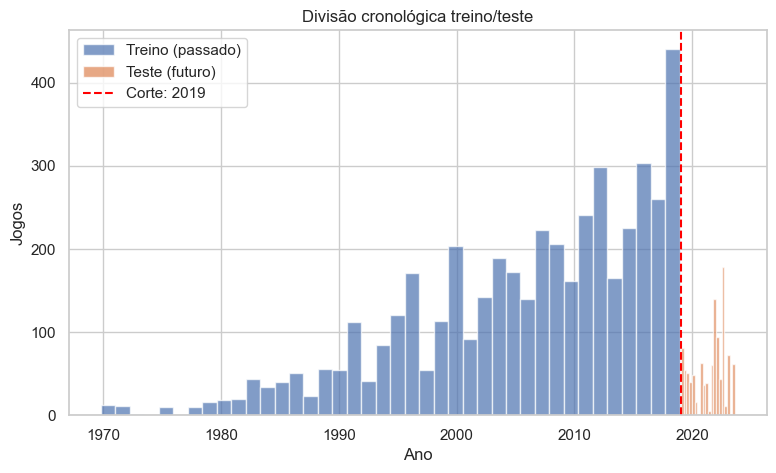

In [ ]:
corte = pd.Timestamp("2019-01-01")

treino = jogos[jogos["date"] < corte]
teste  = jogos[jogos["date"] >= corte]

print(f"Jogos de TREINO (antes de 2019): {len(treino)}")
print(f"Jogos de TESTE  (2019 em diante): {len(teste)}")

# Visualiza a divisão na linha do tempo
plt.figure()
plt.hist(treino["date"], bins=40, label="Treino (passado)", alpha=0.7)
plt.hist(teste["date"],  bins=20, label="Teste (futuro)",  alpha=0.7)
plt.axvline(corte, color="red", linestyle="--", label="Corte: 2019")
plt.title("Divisão cronológica treino/teste")
plt.legend(); plt.xlabel("Ano"); plt.ylabel("Jogos")
plt.show()

In [ ]:
# Escolhemos os ATRIBUTOS (features) que o modelo vai usar
atributos = ["elo_casa", "elo_visitante", "elo_diferenca", "campo_neutro"]

X_treino, y_treino = treino[atributos], treino["resultado"]
X_teste,  y_teste  = teste[atributos],  teste["resultado"]

print("Formato dos dados de treino:", X_treino.shape)
print("Formato dos dados de teste: ", X_teste.shape)

Formato dos dados de treino: (4560, 4)
Formato dos dados de teste:  (1097, 4)


## 6. Modelo "chute básico" (baseline) 🎯

Antes de usar Machine Learning, criamos um **baseline**: uma regra bem simples
para servir de comparação. Se o ML não for melhor que o chute básico, ele não vale a pena!

Nosso baseline: **"sempre aposte na vitória da casa"** (o resultado mais comum).

In [ ]:
palpite_baseline = np.full(len(y_teste), 2)   # 2 = vitória da casa
acc_baseline = accuracy_score(y_teste, palpite_baseline)
print(f"Acurácia do baseline (sempre casa): {acc_baseline*100:.1f}%")

Acurácia do baseline (sempre casa): 50.3%


## 7. Treinando os modelos de Machine Learning 🤖

Agora sim! Vamos treinar **dois** modelos e comparar:

1. **Regressão Logística** — um modelo simples e rápido.
2. **Random Forest** (Floresta Aleatória) — combina muitas "árvores de decisão".

Treinar = mostrar os jogos do passado (treino) para o modelo aprender os padrões.

In [ ]:
# Modelo 1: Regressão Logística
modelo_rl = LogisticRegression(max_iter=1000)
modelo_rl.fit(X_treino, y_treino)
acc_rl = accuracy_score(y_teste, modelo_rl.predict(X_teste))

# Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_rf.fit(X_treino, y_treino)
acc_rf = accuracy_score(y_teste, modelo_rf.predict(X_teste))

print(f"Baseline (sempre casa) : {acc_baseline*100:.1f}%")
print(f"Regressão Logística    : {acc_rl*100:.1f}%")
print(f"Random Forest          : {acc_rf*100:.1f}%")

Baseline (sempre casa) : 50.3%
Regressão Logística    : 69.6%
Random Forest          : 64.8%


C:\Users\xx-re\AppData\Local\Temp\ipykernel_32880\1114588153.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=modelos, y=acuracias, palette="rocket")


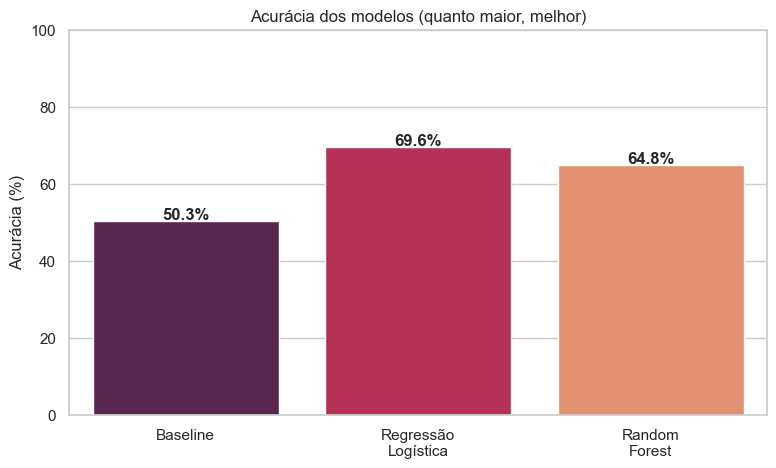

In [ ]:
# Gráfico comparativo
modelos = ["Baseline", "Regressão\nLogística", "Random\nForest"]
acuracias = [acc_baseline*100, acc_rl*100, acc_rf*100]

plt.figure()
barras = sns.barplot(x=modelos, y=acuracias, palette="rocket")
for i, v in enumerate(acuracias):
    barras.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
plt.title("Acurácia dos modelos (quanto maior, melhor)")
plt.ylabel("Acurácia (%)"); plt.ylim(0, 100)
plt.show()

🎉 Os modelos de ML acertam **muito mais** que o chute básico!
A **Regressão Logística** costuma ir muito bem aqui, porque a relação entre a
diferença de Elo e o resultado é bastante "suave".

### 7.1 A matriz de confusão

A **matriz de confusão** mostra onde o modelo acerta e onde erra. As linhas são
o resultado **real** e as colunas o que o modelo **previu**. A diagonal são os acertos.

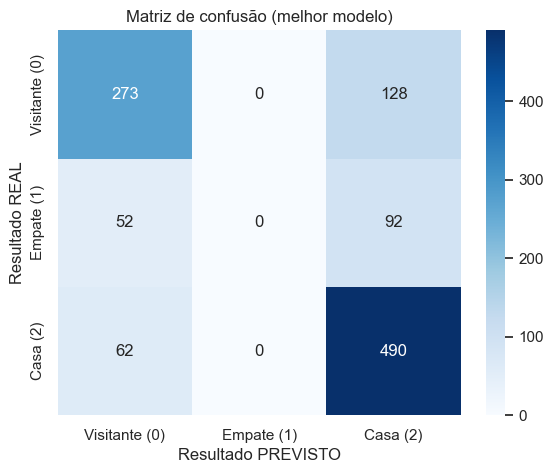

Empates são os mais difíceis de prever — você consegue imaginar por quê? 🤔


In [ ]:
melhor = modelo_rl if acc_rl >= acc_rf else modelo_rf
previsoes = melhor.predict(X_teste)

cm = confusion_matrix(y_teste, previsoes)
rot = ["Visitante (0)", "Empate (1)", "Casa (2)"]

plt.figure(figsize=(6.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=rot, yticklabels=rot)
plt.title("Matriz de confusão (melhor modelo)")
plt.ylabel("Resultado REAL"); plt.xlabel("Resultado PREVISTO")
plt.show()

print("Empates são os mais difíceis de prever — você consegue imaginar por quê? 🤔")

## 8. Aplicação: prevendo jogos do **Brasil** 🇧🇷

Agora a parte mais divertida: vamos ver como o modelo se saiu nas partidas da
**Seleção Brasileira Feminina** dentro do período de teste (2019+).

In [ ]:
# Pega os jogos de teste em que o Brasil jogou
brasil = teste[(teste["home_team"] == "Brazil") | (teste["away_team"] == "Brazil")].copy()
brasil["previsto"] = melhor.predict(brasil[atributos])

nomes = {2: "Vitória casa", 1: "Empate", 0: "Vitória visitante"}
tabela = pd.DataFrame({
    "Data": brasil["date"].dt.date,
    "Casa": brasil["home_team"],
    "Visitante": brasil["away_team"],
    "Placar": brasil["home_score"].astype(str) + "x" + brasil["away_score"].astype(str),
    "Resultado real": brasil["resultado"].map(nomes),
    "Previsão do modelo": brasil["previsto"].map(nomes),
})
tabela["Acertou?"] = np.where(brasil["resultado"].values == brasil["previsto"].values, "✅", "❌")

acertos = (brasil["resultado"].values == brasil["previsto"].values).mean()
print(f"O modelo acertou {acertos*100:.0f}% dos jogos do Brasil no período de teste.\n")
tabela.head(15)

O modelo acertou 68% dos jogos do Brasil no período de teste.



,Data,Casa,Visitante,Placar,Resultado real,Previsão do modelo,Acertou?
4580,2019-02-27,England,Brazil,2x1,Vitória casa,Vitória casa,✅
4603,2019-03-02,Brazil,Japan,1x3,Vitória visitante,Vitória casa,❌
4621,2019-03-05,United States,Brazil,1x0,Vitória casa,Vitória casa,✅
4649,2019-06-09,Brazil,Jamaica,3x0,Vitória casa,Vitória casa,✅
4660,2019-06-13,Australia,Brazil,3x2,Vitória casa,Vitória casa,✅
4673,2019-06-18,Italy,Brazil,0x1,Vitória visitante,Vitória visitante,✅
4684,2019-06-23,France,Brazil,2x1,Vitória casa,Vitória casa,✅
4715,2019-08-30,Brazil,Argentina,5x0,Vitória casa,Vitória casa,✅
4725,2019-09-01,Brazil,Chile,0x0,Empate,Vitória casa,❌
4779,2019-11-07,Brazil,Canada,4x0,Vitória casa,Vitória casa,✅


## 9. Exercícios para você continuar 🚀

Tente modificar o notebook e ver o que acontece:

1. **Mude o corte** da divisão cronológica (ex.: 2017 ou 2021). O modelo melhora ou piora?
2. **Mexa no `fator_casa`** e no `K` da função de Elo. Como isso afeta a acurácia?
3. **Crie um novo atributo**: a "forma recente" (média de gols nos últimos 5 jogos).
4. Teste outro modelo do `sklearn`, como `KNeighborsClassifier`.
5. Faça o modelo prever um jogo **hipotético**: Brasil (casa) x Estados Unidos.
   Dica: monte uma linha com os ratings Elo finais das duas seleções!

> **Reflexão:** por que prever futebol é tão difícil? O que o modelo **não sabe**
> (lesões, técnico, motivação...) também importa muito. ML não é uma bola de cristal —
> é uma ferramenta para estimar **probabilidades** a partir do que já aconteceu.
